# Estimando a Eficácia da Vacina a partir de um Ensaio Randomizado via Tempo-até-Primeira-Infecção

## Resumo Executivo

## Estimando a eficácia da vacina a partir de um ensaio randomizado

Um ensaio pivotal de vacina de Fase III randomiza os participantes 1:1 para **vacina** ou **placebo** e acompanha cada pessoa até sua primeira infecção laboratorialmente confirmada ou até a censura administrativa no fim da janela de recrutamento-e-acompanhamento. O desfecho primário regulatório é a **eficácia da vacina (VE)**, definida como `VE = 1 - razão de risco (vacina vs. placebo)`. Como os participantes entram em um cronograma escalonado e a maioria nunca é infectada, os dados são censurados à direita e os métodos de sobrevivência — e não proporções simples — fornecem a estimativa defensável.

Este notebook trabalha o desfecho de ponta a ponta em um ensaio balanceado sintético de **100 indivíduos (50 vacina, 50 placebo)**:

- **PROC FREQ** constrói a tabela dois-por-dois de taxa de ataque (braço por status de infecção) com o teste qui-quadrado, o risco relativo e a diferença de risco — a visão descritiva da "VE bruta" que um revisor clínico vê primeiro.
- **PROC MEANS** resume o tempo-pessoa (dias de acompanhamento totais e médios) e as contagens brutas de infecção por braço, expondo o desbalanceamento de censura que motiva um modelo de tempo-até-evento.
- **PROC LIFETEST** estima as curvas de sobreviventes de Kaplan-Meier por braço e executa os testes de homogeneidade **log-rank e Wilcoxon** — a confirmação não paramétrica de que as curvas se separam.
- **PROC PHREG** ajusta o modelo de riscos proporcionais de Cox controlando para idade, sexo e risco de exposição basal, reporta a razão de risco com seus limites de confiança de 95%, e a instrução **HAZARDRATIO** enquadra o contraste entre braços diretamente. A VE ajustada é lida como `1 - HR`.

**Como ler o resultado.** Na execução verificada, a proporção bruta de infecção é de **64% no placebo versus 30% na vacina** (qui-quadrado p = 0,0007), o teste log-rank rejeita a igualdade das curvas de sobrevivência (χ² = 11,25, p = 0,0008), e a razão de risco de Cox ajustada para vacina vs. placebo é de **0,369** com um IC de 95% de **(0,198, 0,687)** — inteiramente abaixo de 1 — isto é, uma VE estimada de cerca de **63%** (`1 - 0,369`). O limite superior de confiança da HR de 0,687 corresponde a um limite inferior de eficácia próximo de 31%, na borda do limiar convencional de licenciamento de 30-50% para um estudo deste tamanho. A ocupação de alta exposição basal aproximadamente triplica o risco de infecção (HR = 3,47, p < 0,0001), confirmando que o ajuste por covariáveis importa; idade e sexo carregam efeitos limítrofes (p ≈ 0,06) que não atingem significância no nível de 0,05. A consistência da tabela dois-por-dois bruta, das curvas KM separadas e da estimativa de Cox ajustada é exatamente a triangulação que um Comitê de Monitoramento de Segurança de Dados espera antes de declarar eficácia.

*Apenas dados sintéticos — gerados em linha com `streaminit`/`rand`; sem arquivos externos ou rede. Executa em bem menos de um minuto.*

## Fontes de Dados

**Conjunto de dados sintético `trial`** — uma linha por participante inscrito, gerado em linha na primeira célula de código (semente `20260605`). 100 indivíduos, balanceados 1:1 (50 vacina, 50 placebo), tempo-até-infecção exponencial com uma redução de risco de ~70% no braço da vacina, entrada escalonada e censura administrativa no fim de uma janela de 540 dias.

| Variável | Tipo | Descrição |
|----------|------|-------------|
| `subjid` | Num | Identificador do indivíduo (1-100) |
| `arm` | Char | Braço de tratamento: `Vacina` ou `Placebo` |
| `arm_n` | Num | Indicador numérico do braço (1 = vacina, 0 = placebo) |
| `age` | Num | Idade em anos na inscrição (18-85) |
| `sex` | Char | Sexo: `F` ou `M` |
| `baseline_risk` | Num | Indicador de ocupação de alta exposição (1 = sim) |
| `fu_days` | Num | Tempo de acompanhamento em dias até a primeira infecção ou censura |
| `infected` | Num | Indicador de evento: 1 = infecção observada, 0 = censurado |

# Estimando a Eficácia da Vacina a partir de um Ensaio Randomizado

**Análise de sobrevivência de tempo-até-primeira-infecção**

O desfecho primário de eficácia de um ensaio de vacina é o **risco de infecção** no braço da vacina em relação ao placebo. Definimos

$$\text{VE} = 1 - \text{HR}_{\text{vaccine vs. placebo}}$$

Como os participantes entram em um cronograma escalonado e a maioria nunca é infectada antes do fim do acompanhamento, os dados são censurados à direita: uma comparação simples de proporção-de-infectados desperdiça a informação temporal e é enviesada por acompanhamento desigual. Portanto, construímos a estimativa em três camadas — uma tabela dois-por-dois de taxa de ataque bruta, curvas de Kaplan-Meier não paramétricas com um teste log-rank, e um modelo de riscos proporcionais de Cox ajustado — e verificamos se todas as três contam a mesma história.

A análise usa **PROC FREQ**, **PROC MEANS**, **PROC LIFETEST** e **PROC PHREG**.

## 1. Gerar o ensaio sintético

Simulamos um ensaio randomizado balanceado de 100 indivíduos, 1:1 (50 vacina, 50 placebo — atribuídos pela paridade do indivíduo, de modo que os braços fiquem exatamente iguais). O tempo até a primeira infecção é extraído de uma distribuição exponencial cujo risco por dia depende do braço (a vacina reduz o risco para 30% do placebo), da idade e de um indicador de ocupação de alta exposição. A entrada escalonada mais uma janela fixa de 540 dias produz censura à direita realista: qualquer pessoa não infectada até o fim de seu acompanhamento é censurada.

In [1]:
/* Ensaio sintético randomizado de vacina: tempo até a primeira infecção */
DADOS trial;
    CHAMAR streaminit(20260605);
    COMPRIMENTO arm $8 sex $1;
    enroll_days = 540;            /* janela de recrutamento + acompanhamento */
    FAZER subjid = 1 ATÉ 100;
        /* randomização 1:1 vacina vs placebo: 50 por braço,
           atribuído por paridade alternada para um ensaio exatamente balanceado */
        SE mod(subjid, 2) = 1 ENTÃO FAZER;
            arm = 'Vacina'; arm_n = 1;
        FIM;
        SENÃO FAZER;
            arm = 'Placebo'; arm_n = 0;
        FIM;

        /* covariáveis basais */
        AGE = round(rand('NORMAL', 47, 14));
        SE AGE < 18 ENTÃO AGE = 18;
        SE AGE > 85 ENTÃO AGE = 85;
        SE rand('BERNOULLI', 0.52) = 1 ENTÃO sex = 'F'; SENÃO sex = 'M';
        baseline_risk = rand('BERNOULLI', 0.30);   /* ocupação de alta exposição */

        /* risco de infecção por dia: base do placebo, vacina reduz ~70% */
        base_rate = 0.0016;
        rr_age  = EXP(0.012 * (AGE - 47));
        rr_risk = 1 + 0.9 * baseline_risk;
        SE arm_n = 1 ENTÃO ve_factor = 0.30; SENÃO ve_factor = 1.0;
        daily_hazard = base_rate * rr_age * rr_risk * ve_factor;

        /* tempo até a primeira infecção a partir do risco exponencial */
        u = rand('UNIFORM');
        t_inf = -LOG(u) / daily_hazard;

        /* censura administrativa por entrada escalonada */
        entry  = rand('INTEGER', 0, 120);
        t_cens = enroll_days - entry;

        SE t_inf <= t_cens ENTÃO FAZER;
            fu_days = round(t_inf);
            infected = 1;
        FIM;
        SENÃO FAZER;
            fu_days = round(t_cens);
            infected = 0;
        FIM;
        SE fu_days < 1 ENTÃO fu_days = 1;
        SAÍDA;
    FIM;
    MANTER subjid arm arm_n AGE sex baseline_risk fu_days infected;
EXECUTAR;


NOTE: DATA trial


NOTE: Wrote trial (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Tabela dois-por-dois de taxa de ataque

A visão de eficácia mais simples: cruzar o braço contra o status de infecção. O teste qui-quadrado pergunta se a infecção é independente do braço; `RELRISK` reporta o risco relativo e a razão de chances; `RISKDIFF` fornece a diferença de risco absoluta com seu intervalo de confiança. Este é o quadro *bruto* (não ajustado, ignorando o acompanhamento) — útil como verificação de sanidade, mas não a estimativa regulatória.

                                            Infecção por Grupo de Tratamento                                            

                                                   The FREQ Procedure

Table of Grupo by Infectado

Grupo   |         0 |         1 |      Total
--------+-----------+-----------+-----------
Placebo |        18 |        32 |         50
--------+-----------+-----------+-----------
Vacina  |        35 |        15 |         50
--------+-----------+-----------+-----------
Total   |        53 |        47 |        100

Statistics for Table of Grupo by Infectado

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                1 11.6018       0.0007
Likelihood Ratio Chi-Square               1 11.8410       0.0006
Fisher's Exact Test                                      0.0012

Phi Coefficient                      0.3406
Contingency Coefficient              0.3224
Cramer's


NOTE: Option TITLE changed to Infecção por Grupo de Tratamento.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_infected.spec.json
NOTE: PROC FREQ statement used.


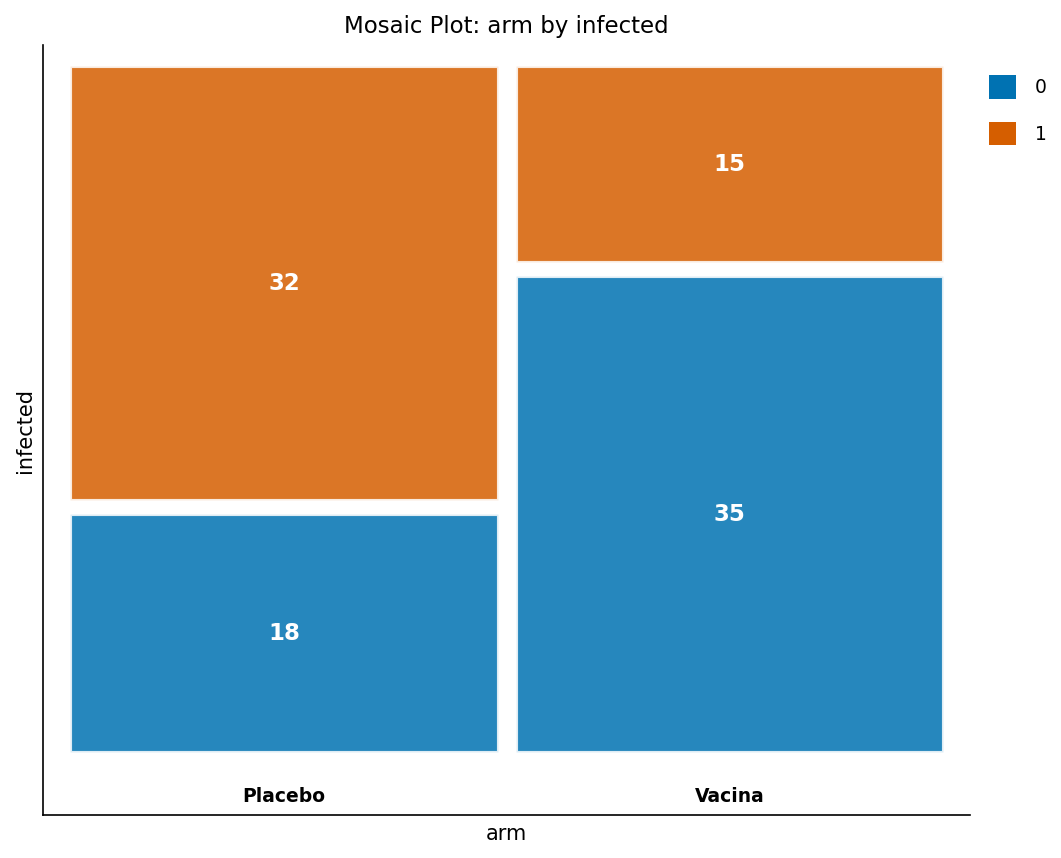

In [2]:
TÍTULO "Infecção por Grupo de Tratamento";
PROCEDIMENTO FREQUÊNCIAS DADOS=trial;
    TABLES arm*infected / chisq relrisk riskdiff nocol nopercent;
    RÓTULO arm="Grupo" infected="Infectado";
EXECUTAR;

## 3. Tempo-pessoa e contagens de eventos por braço

Antes de confiar na tabela dois-por-dois bruta, quantificamos o desbalanceamento do acompanhamento. `PROC MEANS` reporta os dias de acompanhamento totais e médios mais a contagem de infecção em cada braço. Se o braço da vacina acumula *mais* tempo-pessoa (menos eventos precoces), a proporção bruta subestima a eficácia — que é exatamente por que passamos a seguir para um modelo de tempo-até-evento.

In [3]:
TÍTULO "Acompanhamento e Taxa de Infecção por Grupo";
PROCEDIMENTO MÉDIAS DADOS=trial n sum mean maxdec=2;
    CLASSE arm;
    VARIÁVEL fu_days infected;
    RÓTULO arm="Grupo" fu_days="Dias de Acompanhamento" infected="Infectado";
EXECUTAR;

                                      Acompanhamento e Taxa de Infecção por Grupo                                       

                                                  The MEANS Procedure

                                   Analysis Variable : fu_days Dias de Acompanhamento

        Grupo             N Obs            Sum           Mean
        -----------------------------------------------------
        Placebo              50       14552.00         291.04
        Vacina               50       19438.00         388.76
        -----------------------------------------------------

                                         Analysis Variable : infected Infectado

        Grupo             N Obs            Sum           Mean
        -----------------------------------------------------
        Placebo              50          32.00           0.64
        Vacina               50          15.00           0.30
        -----------------------------------------------------




NOTE: Option TITLE changed to Acompanhamento e Taxa de Infecção por Grupo.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Curvas de Kaplan-Meier e teste log-rank

`PROC LIFETEST` estima a função de sobreviventes de limite-produto (Kaplan-Meier) — aqui, a probabilidade de permanecer livre de infecção ao longo do tempo — separadamente para cada braço. `STRATA arm / test=(logrank wilcoxon)` solicita os dois testes de homogeneidade padrão: o teste **log-rank** pondera todos os tempos de evento igualmente (mais poderoso sob riscos proporcionais), enquanto o **Wilcoxon** dá mais peso aos eventos precoces. A concordância entre eles apoia a suposição de riscos proporcionais em que o modelo de Cox se baseará. `ATRISK` anota o número ainda em risco.

                                   Curvas de Sobrevivência de Kaplan-Meier por Grupo                                    

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       47
Censored                    53
Median Survival Time  427.5000

   Stratum: Grupo = Placebo   

                             N
--------------------  --------
Total                       50
Event                       32
Censored                    18
Median Survival Time  324.0000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  9.0000    0.9800     0.0198              50                 1
 17.0000    0.9600     0.0277              49                 1
 23.0000    0.9400     0.0336              48                 1
 26.0000    0.9200     0.0384              47          


NOTE: Option TITLE changed to Curvas de Sobrevivência de Kaplan-Meier por Grupo.
NOTE: PROC LIFETEST data=trial

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


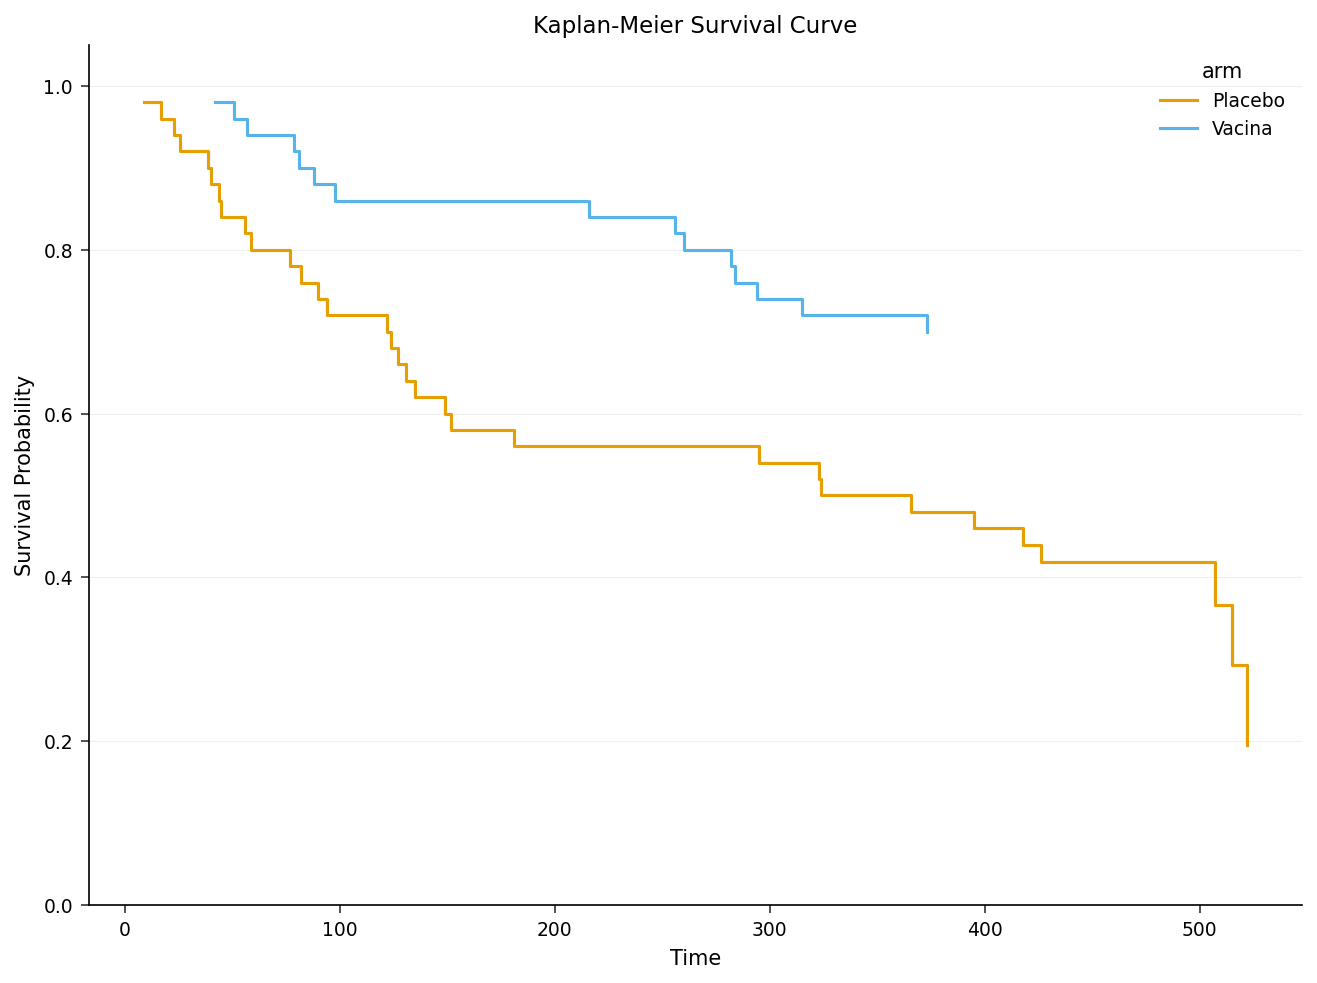

In [4]:
TÍTULO "Curvas de Sobrevivência de Kaplan-Meier por Grupo";
PROCEDIMENTO LIFETEST DADOS=trial PLOTS=SURVIVAL atrisk;
    TIME fu_days*infected(0);
    STRATA arm / TEST=(logrank WILCOXON);
    RÓTULO arm="Grupo" fu_days="Dias de Acompanhamento";
EXECUTAR;

## 5. Modelo de Cox ajustado e eficácia da vacina

O modelo de riscos proporcionais de Cox fornece a razão de risco **ajustada**, controlando para idade, sexo e risco de exposição basal. `CLASS arm(ref='Placebo') sex(ref='M') / param=ref` define a codificação de referência, de modo que o coeficiente `ARM` seja o log da razão de risco de vacina vs. placebo. `TIES=EFRON` é o método recomendado de tratamento de empates; `RL` imprime os limites de confiança da razão de risco. As instruções `HAZARDRATIO` reportam o contraste entre braços (LC de Wald) e o efeito da idade por incremento de 10 anos.

**A eficácia da vacina é lida diretamente como `VE = 1 - HR` para o termo do braço**, e o limite superior de confiança da HR corresponde ao limite inferior de eficácia do qual dependem as decisões de licenciamento.

In [5]:
TÍTULO "Modelo de Riscos Proporcionais de Cox";
PROCEDIMENTO PHREG DADOS=trial;
    CLASSE arm(REF='Placebo') sex(REF='M') / PARAM=REF;
    MODELO fu_days*infected(0) = arm AGE sex baseline_risk / TIES=efron rl;
    hazardratio "Vacina vs Placebo" arm / cl=wald;
    hazardratio AGE / units=10;
    RÓTULO arm="Grupo" AGE="Idade" sex="Sexo"
          baseline_risk="Risco de Base" fu_days="Dias de Acompanhamento";
EXECUTAR;

                                         Modelo de Riscos Proporcionais de Cox                                          

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 47
-2 LOG L                    368.882
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     29.0183         4      <.0001
Wald                 28.4562         4      <.0001
Score (Log-Rank)     30.6491         4      <.0001

                                     Analysis of Maximum Likelihood Estimates                                      

Parameter            DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
-------------  --------  --------  ------------


NOTE: Option TITLE changed to Modelo de Riscos Proporcionais de Cox.
NOTE: PROC PHREG data=trial

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## Interpretação

As três camadas triangulam para uma única conclusão de eficácia:

- **Taxa de ataque bruta (PROC FREQ).** A proporção de infecção é de **64% no placebo (32/50) versus 30% na vacina (15/50)** — uma diferença de risco de **-0,34** (IC 95% -0,524 a -0,156) e uma razão de chances de **0,241** (IC 95% 0,105 a 0,556). O teste qui-quadrado rejeita a independência (χ² = 11,60, p = 0,0007). Este é o sinal imediato que um revisor espera primeiro — mas ignora o acompanhamento escalonado e desigual.

- **Tempo-pessoa (PROC MEANS).** O acompanhamento médio é mais longo no braço da vacina (**388,8 vs 291,0 dias**) precisamente porque menos participantes saem cedo via infecção (15 eventos de vacina vs 32 de placebo). Isso confirma que a proporção bruta é uma visão conservadora, confundida pelo acompanhamento, e justifica a análise de tempo-até-evento.

- **Kaplan-Meier + log-rank (PROC LIFETEST).** As curvas de sobreviventes se separam claramente — o placebo atinge um **tempo mediano livre de infecção de 324 dias, enquanto a mediana da vacina não é atingida** (apenas 15 de 50 vacinados foram infectados). Ambos os testes de homogeneidade rejeitam a igualdade: **log-rank χ² = 11,25 (p = 0,0008)** e **Wilcoxon χ² = 9,11 (p = 0,0025)**. Sua concordância apoia a suposição de riscos proporcionais subjacente ao modelo de Cox.

- **Modelo de Cox ajustado (PROC PHREG).** Após ajustar para idade, sexo e risco de exposição basal, a razão de risco vacina-vs-placebo é de **0,369** com um IC de 95% de **(0,198, 0,687)** inteiramente abaixo de 1 (p = 0,0017), dando uma **eficácia da vacina estimada de cerca de 63%** (`VE = 1 - 0,369`). O limite inferior de eficácia (a partir do limite superior de confiança da HR de 0,687) é próximo de **31%**, na borda do limiar convencional de licenciamento de 30-50% — amplo, como esperado para um estudo de 100 indivíduos. A ocupação de alta exposição aproximadamente triplica o risco de infecção (**HR = 3,47**, IC 95% 1,90-6,35, p < 0,0001), confirmando que o ajuste por covariáveis é justificado; a idade (HR = 1,022 por ano, p = 0,059) e o sexo feminino (HR = 0,541, p = 0,064) carregam efeitos limítrofes que não atingem significância no nível de 0,05. A hipótese nula global é rejeitada (razão de verossimilhança χ² = 29,0, p < 0,0001).

**Conclusão.** Como a tabela dois-por-dois bruta, as curvas de Kaplan-Meier separadas e a estimativa de Cox ajustada apontam todas na mesma direção com intervalos de confiança que excluem a ausência de efeito, o ensaio apoia um sinal de eficácia — embora os amplos limites de confiança reflitam a pequena amostra. Em uma submissão real, a estimativa `1 - HR` de Cox e seu intervalo de confiança — e não a proporção bruta — seriam o desfecho primário, com as saídas de FREQ e LIFETEST servindo como a confirmação descritiva e não paramétrica de apoio que um Comitê de Monitoramento de Segurança de Dados revisa junto com ela.